# ── 왜 p값만으론 부족한가 ──
p값 = "차이가 우연이 아니냐"만 봄 (있냐 없냐)
표본이 크면 아주 작은 차이도 유의하게 나옴 (예: ① AUC 0.554, p=0.0005 → 유의하지만 크기는 작음)
그래서 크기 조건(AUC≥0.65)이 같이 필요: "우연 아닐 뿐 아니라, 쓸모 있을 만큼 커야 함"
GO = AUC ≥ 0.65 또는 AUC ≤ 0.35(크기) AND p<0.05 (우연 아님)  ← 둘 다 필요

가설3의 값도 완벽한 값은 아니지만, 그 이후는 매칭으로 다시 확인.

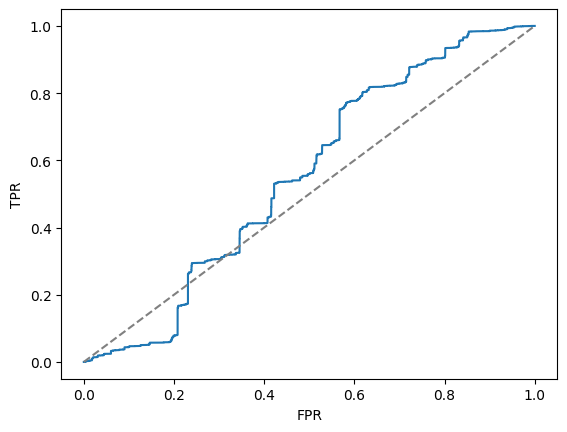

0.5536
AUC 0.5와 차이값: 0.0536


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 가설 1
df = pd.read_csv("killswitch_dataset.csv")

y_test = df['is_cause']
y_score = df['position_ratio']

fpr,tpr,threshold = roc_curve(y_test, y_score)


thm1 = roc_auc_score
plt.plot(fpr,tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

print(f"{thm1(y_test, y_score):.4f}")
print(f"AUC 0.5와 차이값: {abs(thm1(y_test, y_score) - 0.5):.4f}")

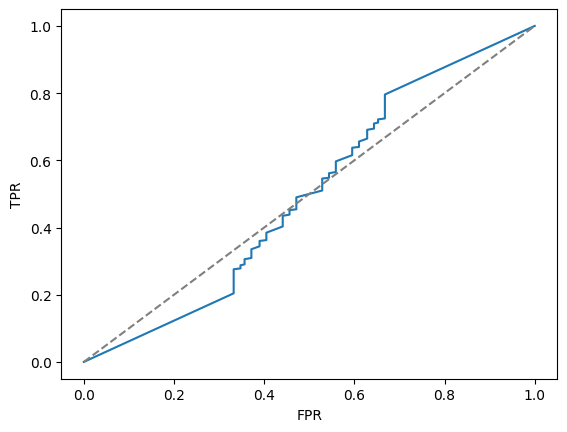

0.5000
AUC 0.5와 차이값: 0.0000


In [3]:
# 가설 2

df = pd.read_csv("killswitch_dataset.csv")

df['5min_grid'] = df['timestamp'] // 300 #5분은 300초

df = df.sort_values(['node', '5min_grid', 'template_id', 'timestamp'])

df['rank'] = df.groupby(['node', '5min_grid', 'template_id']).cumcount()
df['n'] = df.groupby(['node', '5min_grid', 'template_id'])['line_id'].transform('size')

df = df[df['n'] >= 2]

y_score = df['rank'] / (df['n'] - 1)
y_test = df['is_cause']

fpr, tpr, threshold = roc_curve(y_test, y_score)


thm2 = roc_auc_score

plt.plot(fpr,tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

print(f"{thm2(y_test, y_score):.4f}")
print(f"AUC 0.5와 차이값: {abs(thm2(y_test, y_score) - 0.5):.4f}")

/Users/mac/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mac/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


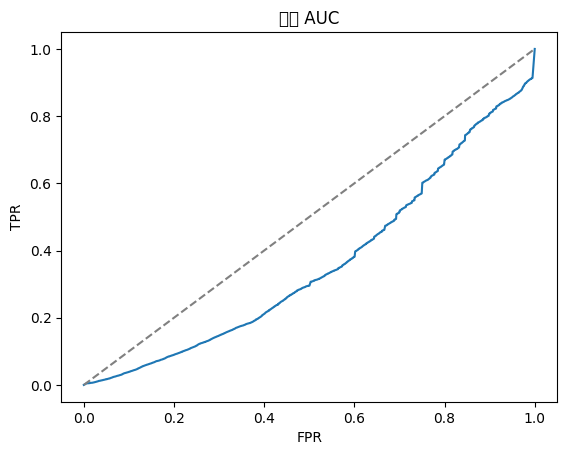

0.3611
AUC 0.5와 차이값: 0.1389
14724


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 가설 3 파일

# group = df.groupby(['node','grid_id_1h'])
# DataFrame.rank(self,  // 랭크함수 기본api
# 		axis = 0, # 기본값 0(index)으로, index 축을 기준으로 랭크가 계산됩니다. 
#     		method = 'average', # 동점을 가진 데이터들의 순위를 매기는 방법입니다.
#     		numeric_only = None, # True로 설정된 경우 숫자 열만 순위를 매깁니다. 
#     		na_option = 'keep', # NaN 값 순위를 매기는 방법입니다.
#     		ascending = True, # 오름차순, 내림차순 정렬인지 정합니다.
#     		pct = False) # 반환 된 순위를 백분위 수 형식으로 표시할지 여부입니다.
# df.groupby('그룹기준열')['순위매길열'].rank() 이건 그룹바이한 열을 기준으로 순서매김 공식

# 1. node + grid_id_1h로 묶어서 rank, 창크기(n) 계산
# 2. n >= 2인 줄만 남김 (1줄 창 제외)   ← 여기서 걸러짐
# 3. 남은 줄들로:
#    - 위치 = rank/(n-1)
#    - is_hardcase = 그 남은 줄들의 is_hardcase
# 4. roc_auc_score(그 is_hardcase, 그 위치)


df = pd.read_csv('positives_grid_1h_2h.csv')

df = df.sort_values(['node', 'grid_id_1h', 'timestamp'])

df['rank'] = df.groupby(['node', 'grid_id_1h']).cumcount()
df['n'] = df.groupby(['node', 'grid_id_1h'])['line_id'].transform('size')

df = df[df['n'] >= 2]

y_score = df['rank'] / (df['n'] - 1)
y_test = df['is_hardcase']

fpr,tpr,threshold = roc_curve(y_test, y_score)



thm3 = roc_auc_score

plt.plot(fpr,tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('위치 AUC')
plt.show()

print(f"{thm3(y_test, y_score):.4f}")
print(f"AUC 0.5와 차이값: {abs(thm3(y_test, y_score) - 0.5):.4f}")

# 셀3의 df에서 양성이 몇 행인가
print(len(df[df['is_hardcase']==1]))


In [8]:
# 순열검정, p값 / 가설 1번
from tqdm import tqdm #진행율 보여주는 라이브러리

result_auc = thm1(y_test, y_score)

n_perm = 5000
count = 0

rng = np.random.default_rng(42)

for i in tqdm(range(n_perm)):
    shuffle = rng.permutation(y_test.values)
    perm_auc = thm1(shuffle, y_score)
    
    if abs(perm_auc - 0.5) >= abs(result_auc - 0.5):
        count += 1
        
p_value = (count + 1) / (n_perm + 1)

print(f"실제 AUC: {result_auc: .4f}")
print(f"p값: {p_value: .4f}")
print("신호 존재" if p_value < 0.05 else "신호 무의미")


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:52<00:00, 95.90it/s] 

실제 AUC:  0.5536
p값:  0.0002
신호 존재


In [ ]:
# 순열검정, p값 / 가설 2번
from tqdm import tqdm #진행율 보여주는 라이브러리

result_auc = thm2(y_test, y_score)

n_perm = 5000
count = 0

rng = np.random.default_rng(42)

for i in tqdm(range(n_perm)):
    shuffle = rng.permutation(y_test.values)
    perm_auc = thm2(shuffle, y_score)
    
    if abs(perm_auc - 0.5) >= abs(result_auc - 0.5):
        count += 1
        
p_value = (count + 1) / (n_perm + 1)

print(f"실제 AUC: {result_auc: .4f}")
print(f"p값: {p_value: .4f}")
print("신호 존재" if p_value < 0.05 else "신호 무의미")


100%|██████████| 5000/5000 [00:16<00:00, 301.29it/s]

실제 AUC:  0.5000
p값:  1.0000
신호 무의미


In [6]:
# 순열검정, p값 / 가설 3번
from tqdm import tqdm #진행율 보여주는 라이브러리

result_auc = thm3(y_test, y_score)

n_perm = 5000
count = 0

rng = np.random.default_rng(42)

for i in tqdm(range(n_perm)):
    shuffle = rng.permutation(y_test.values)
    perm_auc = thm3(shuffle, y_score)
    
    if abs(perm_auc - 0.5) >= abs(result_auc - 0.5):
        count += 1
        
p_value = (count + 1) / (n_perm + 1)

print(f"실제 AUC: {result_auc: .4f}")
print(f"p값: {p_value: .4f}")
print("신호 존재" if p_value < 0.05 else "신호 무의미")


100%|██████████| 5000/5000 [53:22<00:00,  1.56it/s]

실제 AUC:  0.3611
p값:  0.0002
신호 존재
